In [1]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 1 — Bootstrap                                  ║
# ╚══════════════════════════════════════════════════════╝
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

DATA_CFG     = str(PROJECT_ROOT / "config" / "data_config.json")
PIPELINE_CFG = str(PROJECT_ROOT / "config" / "pipeline_config.json")
print(f"Root: {PROJECT_ROOT}")

Root: /storage/emulated/0/Github/hfm


In [2]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 2 — Run Phase 1                                ║
# ╚══════════════════════════════════════════════════════╝
from src.phase1_data_pipeline import run_pipeline

splits, master, reports = run_pipeline(
    data_cfg_path     = DATA_CFG,
    pipeline_cfg_path = PIPELINE_CFG,
    verbose           = True
)


────────────────────────────────────────────────────────────
  PHASE 1 — DATA PIPELINE
────────────────────────────────────────────────────────────
  data_folder : /storage/emulated/0/Github/hfm/data

[·] Loading & cleaning target
    [TARGET] XAUUSD     raw=   20,000  clean=   18,920  dupes=   0  wknd= 1,080  bad_px=  0

[·] Loading & cleaning predictors
    [PRED  ] BCOUSD     raw=   20,000  clean=   19,309  dupes=   0  wknd=   691  bad_px=  0
    [PRED  ] USDJPY     raw=   20,000  clean=   18,752  dupes=   0  wknd= 1,248  bad_px=  0
    [PRED  ] EURUSD     raw=   20,000  clean=   18,750  dupes=   0  wknd= 1,250  bad_px=  0
    [PRED  ] NSXUSD     raw=   20,000  clean=   18,920  dupes=   0  wknd= 1,080  bad_px=  0
    [PRED  ] SPXUSD     raw=   20,000  clean=   18,925  dupes=   0  wknd= 1,075  bad_px=  0
    [PRED  ] UDXUSD     raw=   20,000  clean=   19,301  dupes=   0  wknd=   699  bad_px=  0
    [PRED  ] XAGUSD     raw=   20,000  clean=   18,940  dupes=   0  wknd= 1,060  bad_px= 

In [3]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 3 — Build features on TRAIN split only         ║
# ╚══════════════════════════════════════════════════════╝
import json
from src.phase2_feature_engineering import build_features, validate_features

with open(DATA_CFG)     as f: data_cfg     = json.load(f)
with open(PIPELINE_CFG) as f: pipeline_cfg = json.load(f)

# !! Only ever pass splits["train"] here during research !!
features_train = build_features(
    master       = splits["train"],
    data_cfg     = data_cfg,
    pipeline_cfg = pipeline_cfg,
    apply_lag    = True,
    verbose      = True
)


────────────────────────────────────────────────────────────
  PHASE 2 — FEATURE ENGINEERING  (OPTIMIZED)
  Numba: ✓ enabled
────────────────────────────────────────────────────────────

[A] Price-based features
    → 10 features so far
[B] Momentum features
    → 19 features so far
[C] Volatility features
    → 24 features so far
[D] Structure features
    → 29 features so far
[E] Volume / microstructure features
    → 33 features so far
[F-H] Cross-asset ← BCOUSD
[F-H] Cross-asset ← USDJPY
[F-H] Cross-asset ← EURUSD
[F-H] Cross-asset ← NSXUSD
[F-H] Cross-asset ← SPXUSD
[F-H] Cross-asset ← UDXUSD
[F-H] Cross-asset ← XAGUSD
[H] Basket / dispersion features

  Base features (before lags) : 142
  Applying lags               : [0, 1, 2, 5, 15, 60]
  Total columns (with lags)   : 855
  Warm-up rows dropped        : 1  (11,562 → 11,561)
  Residual NaNs filled        : 107,245 → 0
  Final shape                 : (11561, 855)
────────────────────────────────────────────────────────────


In [4]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 4 — Validate                                   ║
# ╚══════════════════════════════════════════════════════╝
validate_features(features_train, verbose=True)

✅ All 852 features validated
   Bounds : [-1.0000, 1.0000]
   NaN    : 0
   Flat   : 0
   Shape  : (11561, 855)


True

In [5]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 4b — Volume diagnostics                        ║
# ╚══════════════════════════════════════════════════════╝
import pandas as pd

print("=== Volume stats in train split ===")
print(splits["train"]["volume"].describe())
print(f"\nUnique values : {splits["train"]['volume'].nunique()}")
print(f"Zero bars     : {(splits['train']['volume'] == 0).sum()}")
print(f"Constant      : {splits['train']['volume'].std() == 0}")
print(f"\nSample values :\n{splits['train']['volume'].value_counts().head(10)}")

=== Volume stats in train split ===
count    11562.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: volume, dtype: float64

Unique values : 1
Zero bars     : 11562
Constant      : True

Sample values :
volume
0    11562
Name: count, dtype: int64


In [6]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 4c — basket_mom diagnostics                    ║
# ╚══════════════════════════════════════════════════════╝

# Raw RSI values for each predictor
for sym in data_cfg["predictor_symbols"]:
    C_a   = splits["train"][f"{sym}_close"]
    delta = C_a.diff()
    gain  = delta.clip(lower=0).ewm(span=14, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(span=14, adjust=False).mean()
    rs    = gain / loss.replace(0, float("nan")).fillna(1)
    rsi   = 100 - (100 / (1 + rs))
    print(f"{sym:10s}  RSI mean={rsi.mean():.2f}  std={rsi.std():.2f}  "
          f"mapped_std={(rsi/50-1).std():.4f}")

# Basket mean
import pandas as pd, numpy as np
rsi_cols = []
for sym in data_cfg["predictor_symbols"]:
    C_a   = splits["train"][f"{sym}_close"]
    delta = C_a.diff()
    gain  = delta.clip(lower=0).ewm(span=14, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(span=14, adjust=False).mean()
    rs    = gain / loss.replace(0, float("nan")).fillna(1)
    rsi_cols.append((100 - (100 / (1 + rs))) / 50 - 1)

basket = pd.concat(rsi_cols, axis=1).mean(axis=1)
print(f"\nBasket mean={basket.mean():.4f}  std={basket.std():.4f}")

BCOUSD      RSI mean=50.13  std=15.91  mapped_std=0.3182
USDJPY      RSI mean=50.43  std=16.23  mapped_std=0.3246
EURUSD      RSI mean=50.43  std=16.23  mapped_std=0.3246
NSXUSD      RSI mean=50.64  std=16.18  mapped_std=0.3236
SPXUSD      RSI mean=50.66  std=16.09  mapped_std=0.3218
UDXUSD      RSI mean=49.01  std=15.80  mapped_std=0.3161
XAGUSD      RSI mean=51.71  std=15.12  mapped_std=0.3023

Basket mean=0.0073  std=0.1420


In [7]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 5 — Shape & column overview                    ║
# ╚══════════════════════════════════════════════════════╝
feature_cols = [c for c in features_train.columns if not c.startswith("_")]
meta_cols    = [c for c in features_train.columns if c.startswith("_")]

print(f"Shape          : {features_train.shape}")
print(f"Feature cols   : {len(feature_cols)}")
print(f"Meta cols      : {meta_cols}")
print(f"Index range    : {features_train.index[0]}  →  {features_train.index[-1]}")
features_train.head(3)

Shape          : (11561, 855)
Feature cols   : 852
Meta cols      : ['_atr20', '_session', '_close']
Index range    : 2025-12-10 02:18:00+00:00  →  2025-12-22 23:59:00+00:00


,ret_1_lag0,ret_1_lag1,ret_1_lag2,ret_1_lag5,ret_1_lag15,ret_1_lag60,ret_5_lag0,ret_5_lag1,ret_5_lag2,ret_5_lag5,...,dispersion_lag60,leadership_lag0,leadership_lag1,leadership_lag2,leadership_lag5,leadership_lag15,leadership_lag60,_atr20,_session,_close
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-12-10 02:18:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.681905,1,4208.285
2025-12-10 02:19:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.715057,1,4207.935
2025-12-10 02:20:00+00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.695813,1,4207.605


In [8]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 6 — Bounds check (visual)                      ║
# ╚══════════════════════════════════════════════════════╝
import pandas as pd

stats = features_train[feature_cols].agg(["min", "max", "mean", "std"]).T
stats["in_bounds"] = (stats["min"] >= -1.01) & (stats["max"] <= 1.01)
print(f"All in bounds: {stats['in_bounds'].all()}")
stats.sort_values("std", ascending=False).head(20)

All in bounds: True


,min,max,mean,std,in_bounds
hh_score_lag60,-1.0,1.000000,-0.003837,0.817396,True
ll_score_lag60,-1.0,1.000000,-0.057471,0.816773,True
hh_score_lag15,-1.0,1.000000,-0.000047,0.816543,True
hh_score_lag5,-1.0,1.000000,0.000421,0.816402,True
hh_score_lag2,-1.0,1.000000,0.000935,0.816395,True
hh_score_lag0,-1.0,1.000000,0.000951,0.816377,True
hh_score_lag1,-1.0,1.000000,0.000951,0.816377,True
ll_score_lag15,-1.0,1.000000,-0.053542,0.816143,True
ll_score_lag5,-1.0,1.000000,-0.052593,0.815923,True
ll_score_lag2,-1.0,1.000000,-0.052504,0.815876,True


In [9]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 7 — NaN summary                                ║
# ╚══════════════════════════════════════════════════════╝
nan_summary = features_train[feature_cols].isna().sum()
nan_summary = nan_summary[nan_summary > 0]
if nan_summary.empty:
    print("✅ Zero NaN in feature matrix.")
else:
    print(nan_summary)

✅ Zero NaN in feature matrix.


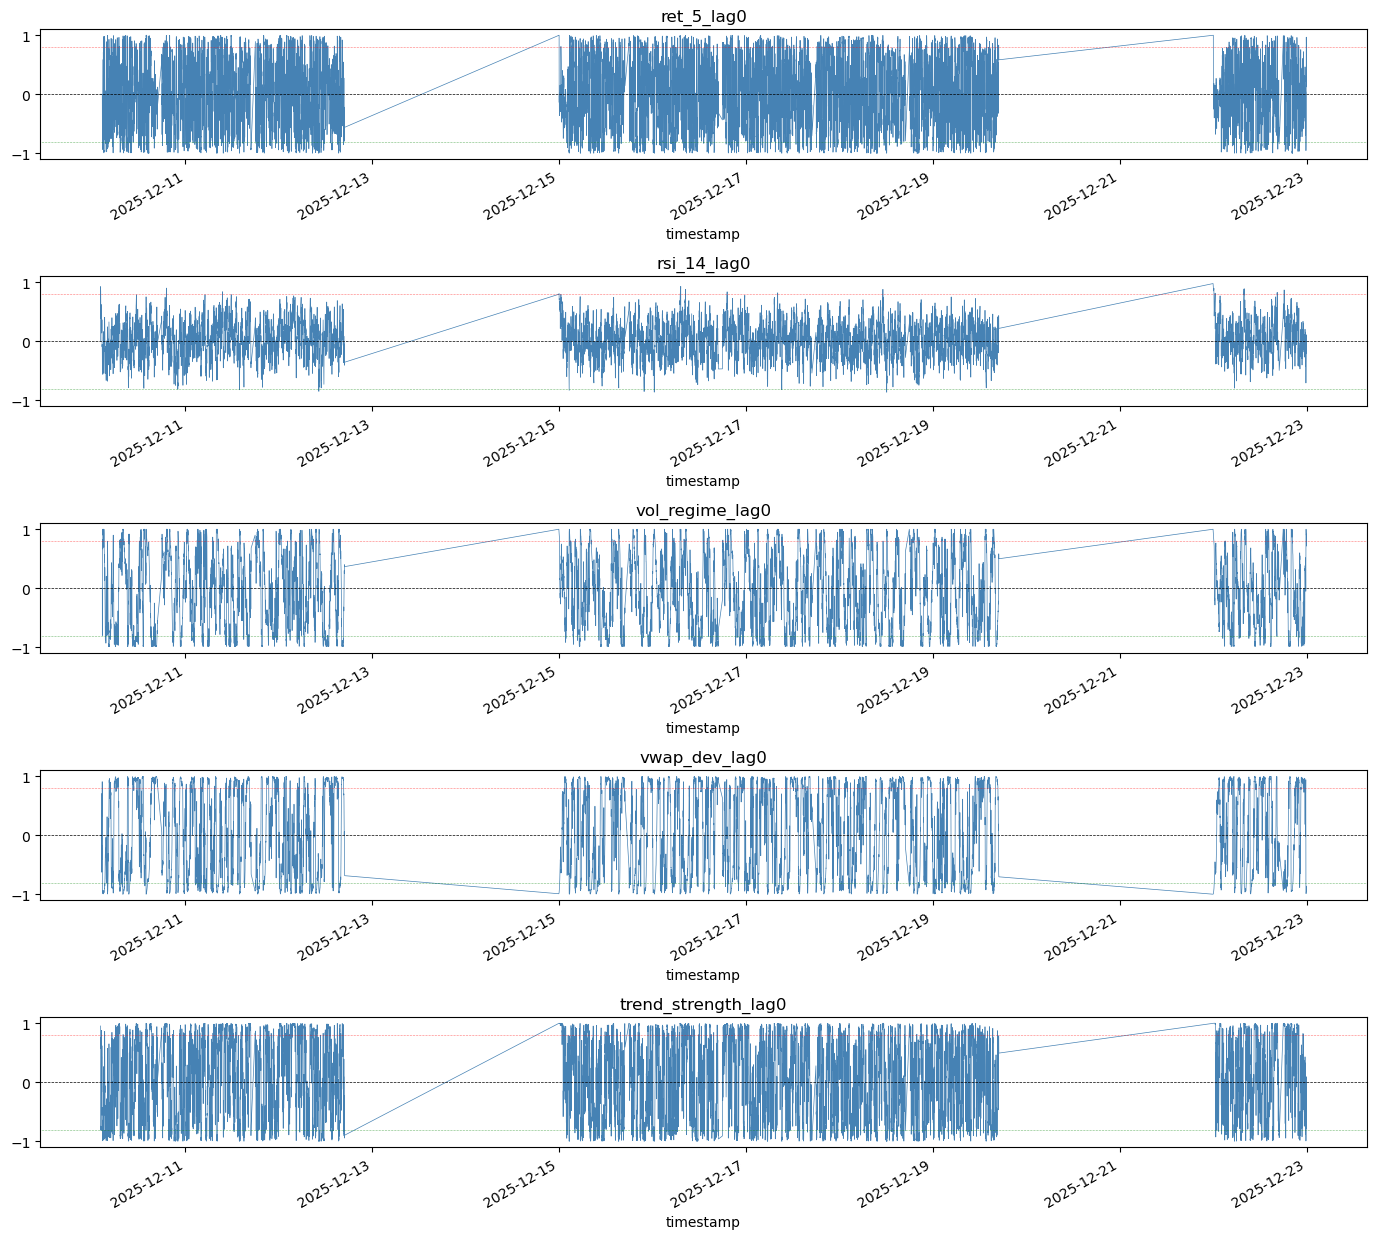

In [10]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 8 — Sample feature plot                        ║
# ╚══════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt

PLOT_FEATS = ["ret_5_lag0", "rsi_14_lag0", "vol_regime_lag0",
              "vwap_dev_lag0", "trend_strength_lag0"]

fig, axes = plt.subplots(len(PLOT_FEATS), 1, figsize=(14, 2.5 * len(PLOT_FEATS)))
for ax, col in zip(axes, PLOT_FEATS):
    if col in features_train.columns:
        features_train[col].plot(ax=ax, lw=0.5, color="steelblue")
        ax.axhline(0,  color="black",  lw=0.5, ls="--")
        ax.axhline(0.8,  color="red",  lw=0.4, ls=":")
        ax.axhline(-0.8, color="green",lw=0.4, ls=":")
        ax.set_title(col)
        ax.set_ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

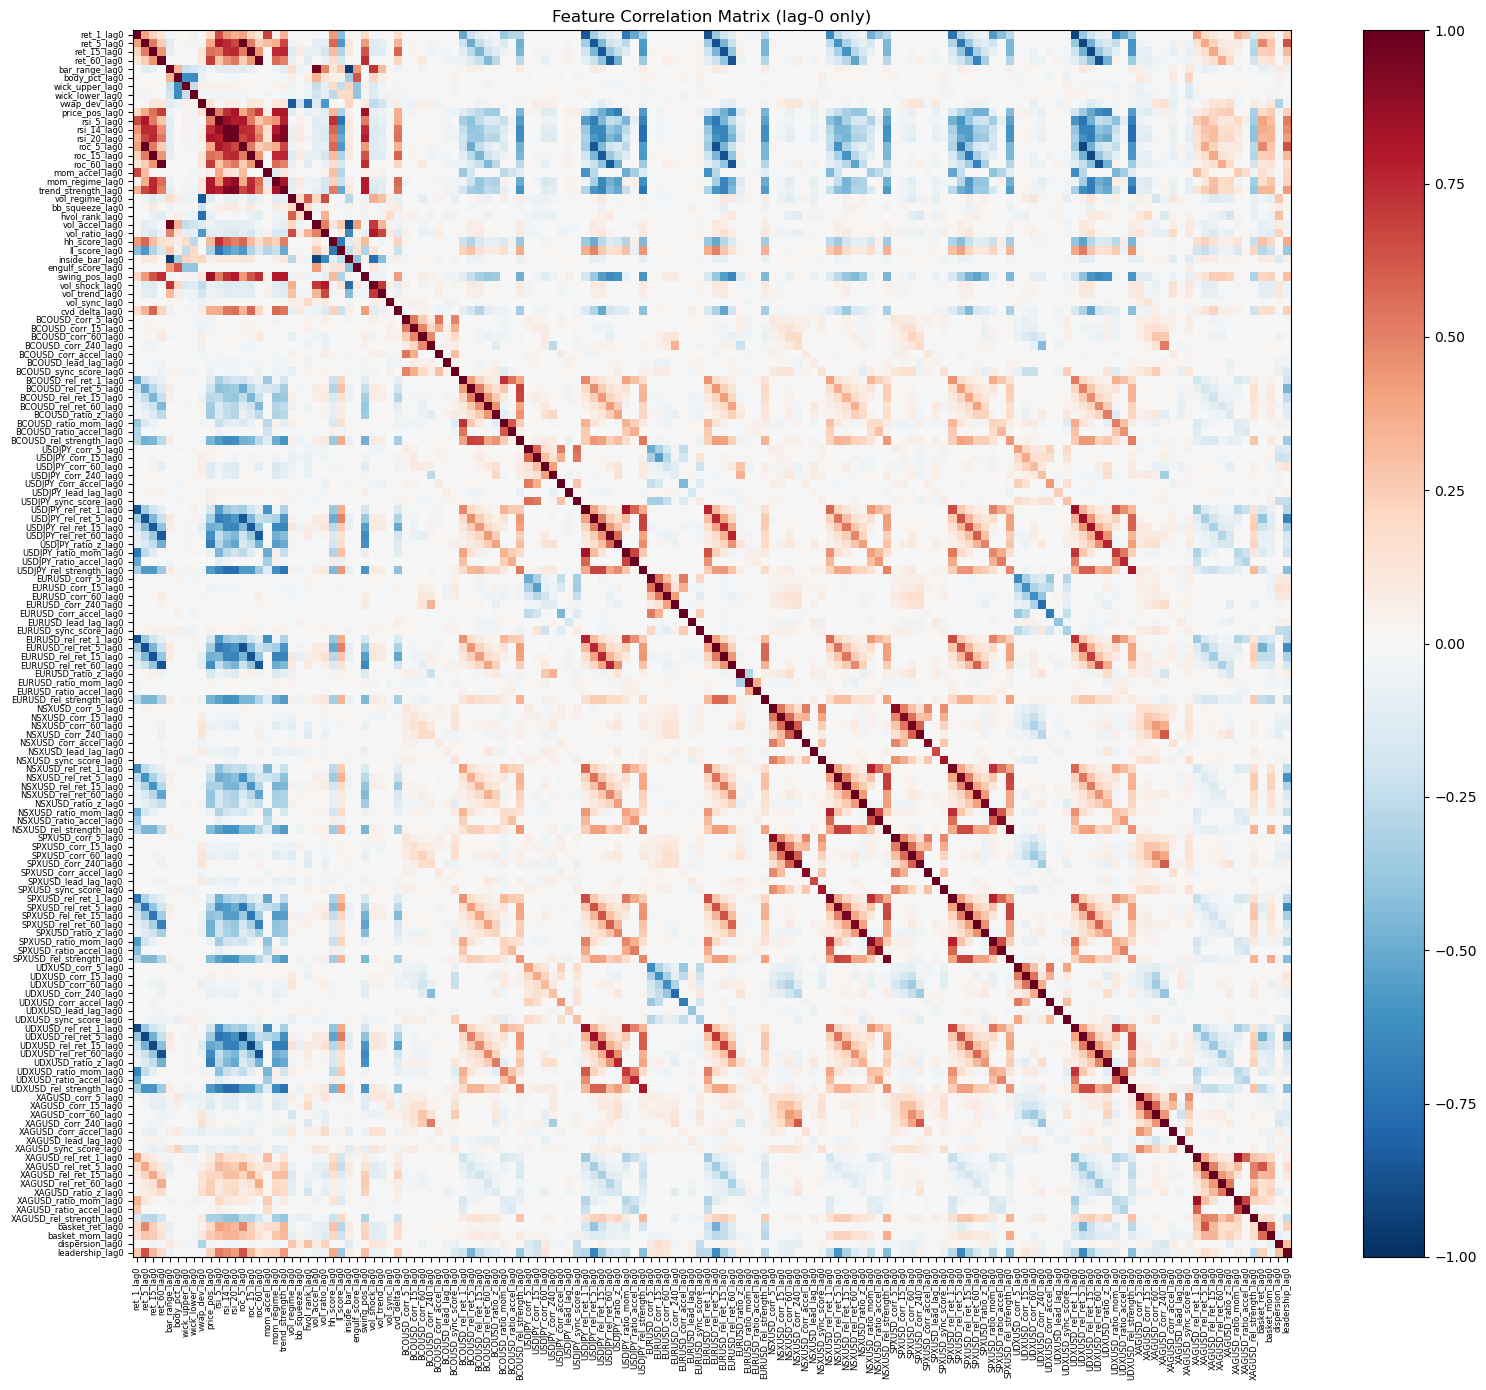

In [11]:
# ╔══════════════════════════════════════════════════════╗
# ║  Cell 9 — Correlation heatmap (base features only)   ║
# ╚══════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt
import numpy as np

# Lag-0 base features only for readability
base_feats = [c for c in feature_cols if c.endswith("_lag0")]
corr_mat   = features_train[base_feats].corr()

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(base_feats)))
ax.set_yticks(range(len(base_feats)))
ax.set_xticklabels(base_feats, rotation=90, fontsize=6)
ax.set_yticklabels(base_feats, fontsize=6)
plt.colorbar(im, ax=ax)
ax.set_title("Feature Correlation Matrix (lag-0 only)")
plt.tight_layout()
plt.show()